# Task 1 — Unsupervised Exploration

1. Load the Palmer Penguins dataset (`sns.load_dataset("penguins")`).
2. Clean the data: handle missing values, examine distributions, and note any anomalies.
3. Select the numeric features and scale them with `StandardScaler`.
4. Apply **PCA** (2 components) and **t-SNE** (2 components, `random_state=42`). Create a side-by-side plot colored by actual species.
5. Apply **K-Means** (k=3) and **DBSCAN** (experiment with at least 2 `eps`/`min_samples` combos) to the scaled data.
6. Evaluate each clustering result with the **silhouette score**.
7. Compare your best clustering labels to the actual species using **adjusted Rand score** and **normalized mutual information**. Visualize the comparison on a PCA projection.
8. In a markdown cell, summarize: How well did unsupervised methods recover the species structure? Where did they fail?

Missing values before cleaning:
 species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Summary statistics:
        bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      333.000000     333.000000         333.000000   333.000000
mean        43.992793      17.164865         200.966967  4207.057057
std          5.468668       1.969235          14.015765   805.215802
min         32.100000      13.100000         172.000000  2700.000000
25%         39.500000      15.600000         190.000000  3550.000000
50%         44.500000      17.300000         197.000000  4050.000000
75%         48.600000      18.700000         213.000000  4775.000000
max         59.600000      21.500000         231.000000  6300.000000


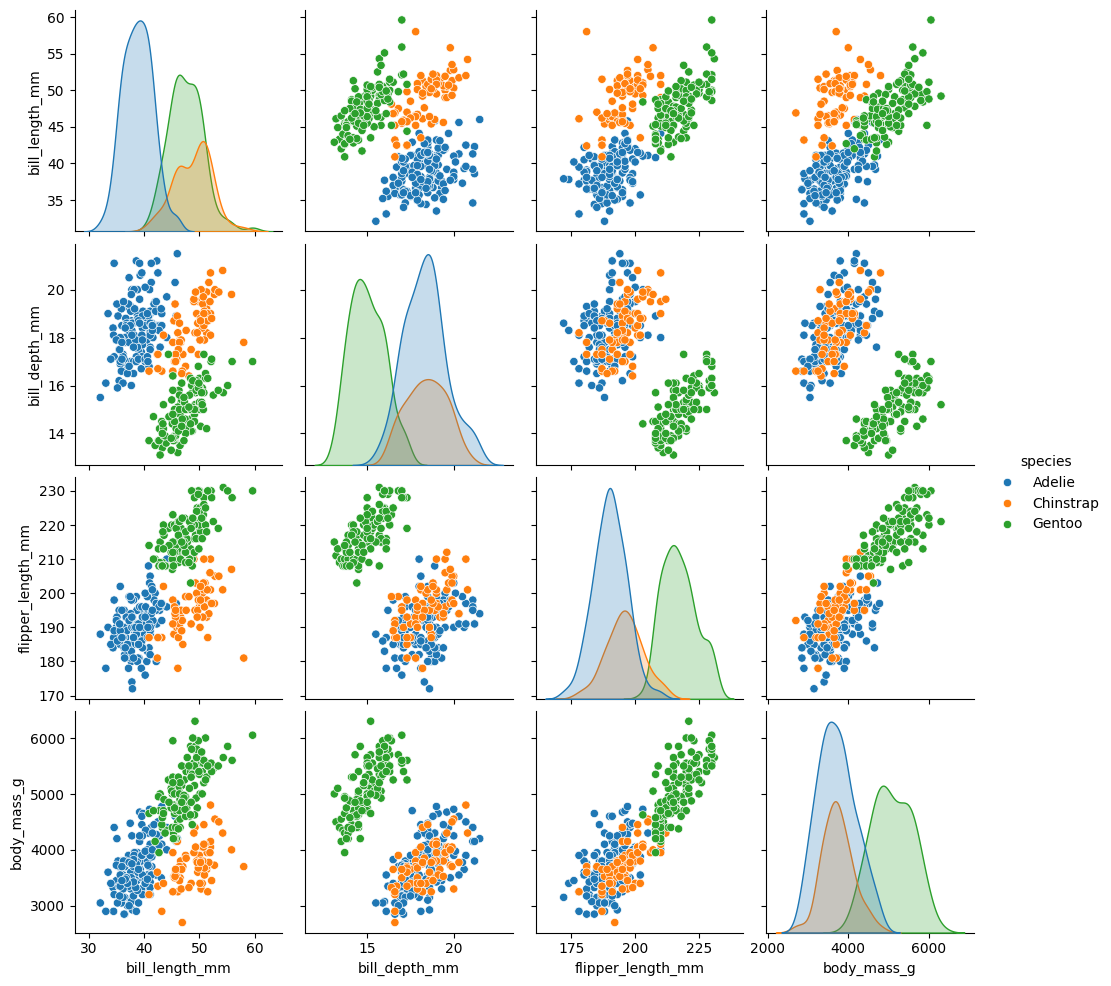

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the dataset
penguins = sns.load_dataset("penguins")

# 2. Clean the data
print("Missing values before cleaning:\n", penguins.isna().sum())

# Drop rows with missing values and reset the index 
# (Resetting is important for alignment later when plotting)
penguins_clean = penguins.dropna().reset_index(drop=True)

# Examine distributions and note anomalies
print("\nSummary statistics:\n", penguins_clean.describe())

# Optional: Uncomment the lines below to visually examine the distributions
sns.pairplot(penguins_clean, hue="species")
plt.show()

In [36]:
from sklearn.preprocessing import StandardScaler

# Select the four numeric features
numeric_features = [
    'bill_length_mm', 
    'bill_depth_mm', 
    'flipper_length_mm', 
    'body_mass_g'
]
X = penguins_clean[numeric_features]

# Scale the features to have a mean of 0 and variance of 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

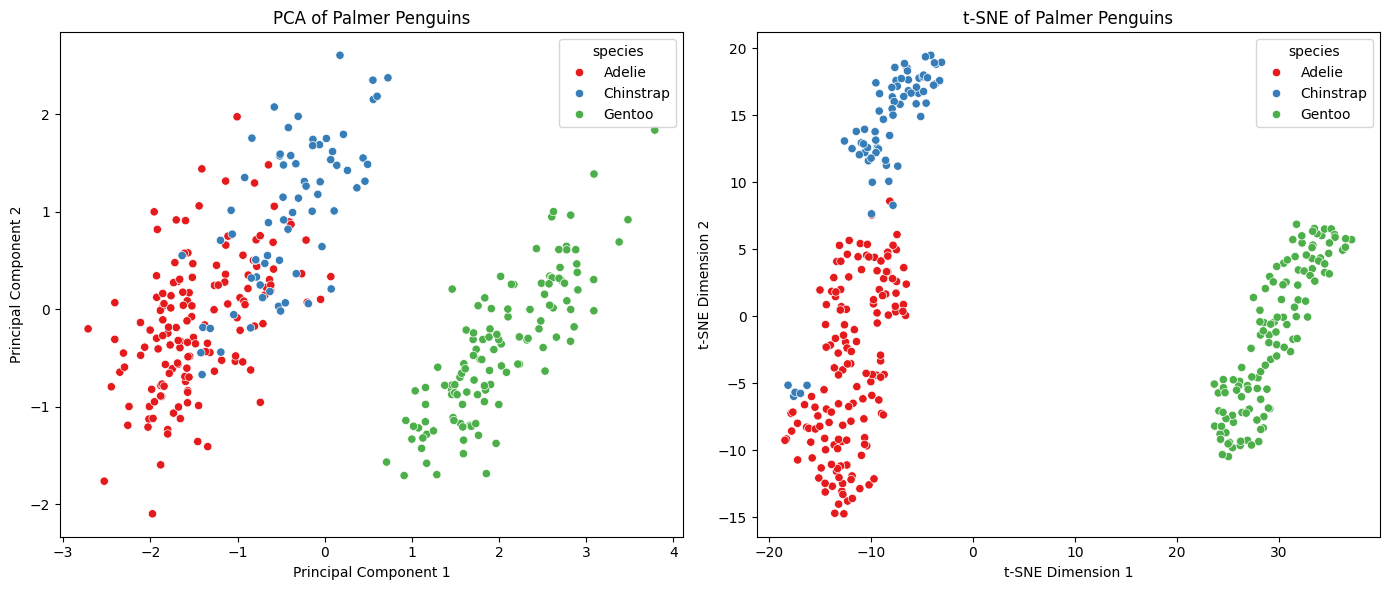

array([0.68633893, 0.19452929])

In [37]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Apply PCA
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(X_scaled)

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42)
tsne_result = tsne.fit_transform(X_scaled)

# Create a side-by-side plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PCA Plot
sns.scatterplot(
    x=pca_result[:, 0], y=pca_result[:, 1],
    hue=penguins_clean['species'], palette='Set1', ax=axes[0]
)
axes[0].set_title('PCA of Palmer Penguins')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')

# t-SNE Plot
sns.scatterplot(
    x=tsne_result[:, 0], y=tsne_result[:, 1],
    hue=penguins_clean['species'], palette='Set1', ax=axes[1]
)
axes[1].set_title('t-SNE of Palmer Penguins')
axes[1].set_xlabel('t-SNE Dimension 1')
axes[1].set_ylabel('t-SNE Dimension 2')

plt.tight_layout()
plt.show()

pca.explained_variance_ratio_

In [38]:
from sklearn.cluster import KMeans, DBSCAN

# Apply K-Means (k=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Apply DBSCAN - Experiment 1 (Tighter clusters)
dbscan_1 = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels_1 = dbscan_1.fit_predict(X_scaled)

# Apply DBSCAN - Experiment 2 (Looser clusters)
# A larger eps is often needed for 4D scaled data
dbscan_2 = DBSCAN(eps=1.0, min_samples=5)
dbscan_labels_2 = dbscan_2.fit_predict(X_scaled)

In [39]:
import numpy as np
from sklearn.metrics import silhouette_score

print("--- Silhouette Scores ---")

# K-Means evaluation
kmeans_score = silhouette_score(X_scaled, kmeans_labels)
print(f"K-Means (k=3): {kmeans_score:.4f}")

# Helper function to safely calculate DBSCAN silhouette score
def evaluate_dbscan(labels, name):
    # Check if there's more than 1 unique label (excluding noise) to compute score
    unique_labels = set(labels)
    if len(unique_labels) > 1 and not (len(unique_labels) == 2 and -1 in unique_labels):
        score = silhouette_score(X_scaled, labels)
        print(f"{name}: {score:.4f} (Found {len(unique_labels) - (1 if -1 in unique_labels else 0)} clusters)")
    else:
        print(f"{name}: Could not calculate score (found 1 or 0 valid clusters).")

# DBSCAN evaluations
evaluate_dbscan(dbscan_labels_1, "DBSCAN (eps=0.5, min_samples=5)")
evaluate_dbscan(dbscan_labels_2, "DBSCAN (eps=1.0, min_samples=5)")

--- Silhouette Scores ---
K-Means (k=3): 0.4462
DBSCAN (eps=0.5, min_samples=5): 0.2516 (Found 4 clusters)
DBSCAN (eps=1.0, min_samples=5): 0.4669 (Found 2 clusters)


Adjusted Rand Score (ARI): 0.7994
Normalized Mutual Information (NMI): 0.7899


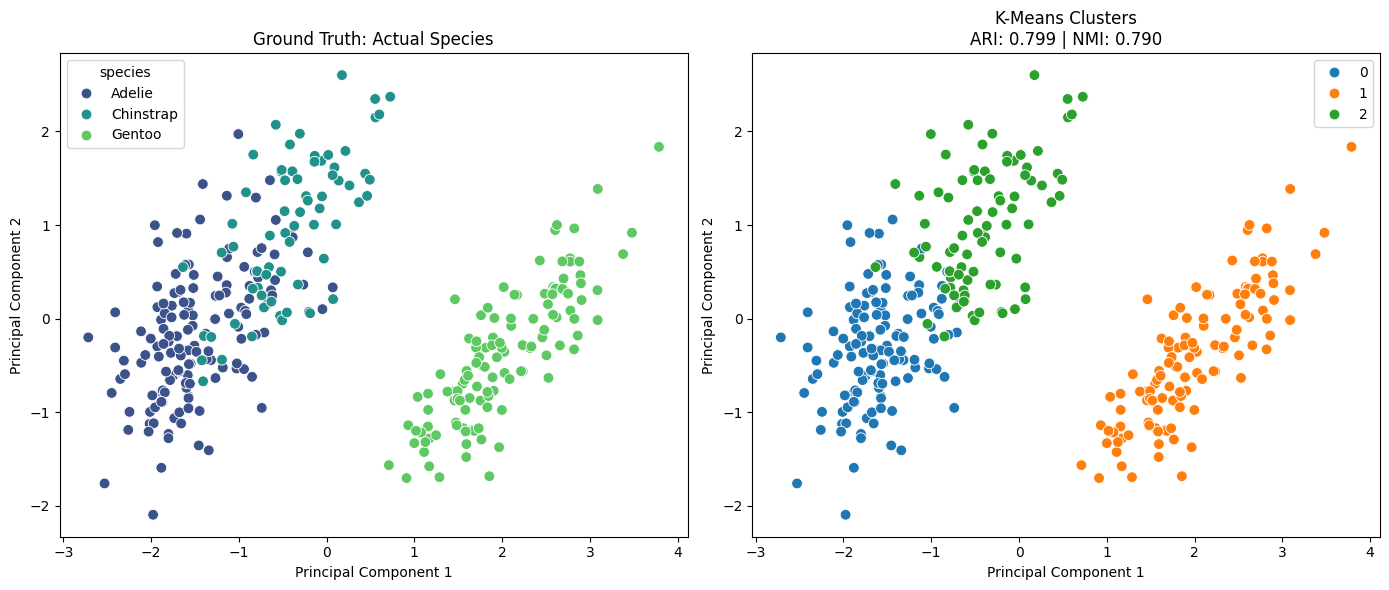

In [40]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Calculate metrics comparing K-Means labels to actual species
actual_species = penguins_clean['species']

ari = adjusted_rand_score(actual_species, kmeans_labels)
nmi = normalized_mutual_info_score(actual_species, kmeans_labels)

print(f"Adjusted Rand Score (ARI): {ari:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")

# Visualize the comparison on the existing PCA projection
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Ground Truth (Actual Species)
sns.scatterplot(
    x=pca_result[:, 0], y=pca_result[:, 1],
    hue=actual_species, palette='viridis', s=60, ax=axes[0]
)
axes[0].set_title('Ground Truth: Actual Species')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')

# Plot 2: K-Means Cluster Assignments
sns.scatterplot(
    x=pca_result[:, 0], y=pca_result[:, 1],
    hue=kmeans_labels, palette='tab10', s=60, ax=axes[1]
)
axes[1].set_title(f'K-Means Clusters\nARI: {ari:.3f} | NMI: {nmi:.3f}')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')

plt.tight_layout()
plt.show()

### Clustering Performance Summary

Based on the evaluation metrics and visual projections , the unsupervised K-Means algorithm ($k=3$) did a very good job recovering the overall species structure, achieving an Adjusted Rand Score (ARI) of **0.7994** and a Normalized Mutual Information (NMI) score of **0.7899**. 

**Where it succeeded:**
* **Gentoo Isolation:** The algorithm almost perfectly clustered the Gentoo species (represented by Cluster 1). Because Gentoo penguins have distinctly different physical measurements (like higher body mass and longer flippers) compared to the other two, they form a highly separable, distinct grouping on the right side of the PCA plot (positive PC1).

**Where it failed:**
* **Adelie vs. Chinstrap Overlap:** The unsupervised model failed to accurately separate Adelie and Chinstrap penguins. As seen in the ground truth plot, these two species have highly overlapping feature distributions. Because K-Means assumes spherical clusters and relies strictly on spatial distance to centroids, it drew a somewhat arbitrary geometric boundary through the overlapping mass (splitting them into Clusters 0 and 2), rather than capturing the true biological distinction.

# Task 2 — Supervised Model Pipeline

1. Prepare the full dataset for supervised classification: target = `species`, features = all other columns.
2. Drop rows with missing values using `dropna()`, then build a preprocessing pipeline using `ColumnTransformer`:
   - Numeric features: scale (`StandardScaler`).
   - Categorical features: one-hot encode (`OneHotEncoder`).
3. Train and evaluate **at least 3 different models** (e.g., LogisticRegression, RandomForest, SVC) using **stratified 5-fold cross-validation**. Report accuracy, precision (macro), recall (macro), and F1 (macro) for each.
4. Select the best model based on F1 score.
5. Define a hyperparameter grid (at least 3 parameters) and run `GridSearchCV` with stratified 5-fold CV.
6. Report the best parameters, best CV score, and compare with the default model performance.

In [41]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_validate

# 1. Load the dataset
penguins = sns.load_dataset("penguins")

# 2. Drop rows with missing values
penguins_clean = penguins.dropna().reset_index(drop=True)

# 3. Define target (y) and features (X)
X = penguins_clean.drop('species', axis=1)
y = penguins_clean['species']

In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. Identify feature types
numeric_features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
categorical_features = ['island', 'sex']

# 2. Build the ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ])

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Define the models in a dictionary for easy looping
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Support Vector Classifier (SVC)': SVC(random_state=42)
}

In [44]:
from sklearn.pipeline import Pipeline

# 1. Define evaluation metrics and cross-validation strategy
scoring_metrics = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("--- Supervised Classification Results (5-Fold CV) ---")

# 2. Loop through each model to evaluate
for name, model in models.items():
    # Chain the preprocessor and the current model together
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor), 
        ('classifier', model)
    ])
    
    # Run the cross-validation
    cv_results = cross_validate(pipeline, X, y, cv=cv, scoring=scoring_metrics)
    
    # Extract the mean of each metric across the 5 folds
    acc = cv_results['test_accuracy'].mean()
    prec = cv_results['test_precision_macro'].mean()
    rec = cv_results['test_recall_macro'].mean()
    f1 = cv_results['test_f1_macro'].mean()
    
    # Print the results
    print(f"\n{name}:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision (Macro): {prec:.4f}")
    print(f"  Recall (Macro):    {rec:.4f}")
    print(f"  F1-Score (Macro):  {f1:.4f}")

--- Supervised Classification Results (5-Fold CV) ---

Logistic Regression:
  Accuracy:  0.9940
  Precision (Macro): 0.9958
  Recall (Macro):    0.9897
  F1-Score (Macro):  0.9923

Random Forest:
  Accuracy:  0.9910
  Precision (Macro): 0.9886
  Recall (Macro):    0.9903
  F1-Score (Macro):  0.9891

Support Vector Classifier (SVC):
  Accuracy:  0.9940
  Precision (Macro): 0.9958
  Recall (Macro):    0.9897
  F1-Score (Macro):  0.9923


In [45]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# 1. Define the Pipeline with the selected best model (SVC)
# Assumes 'preprocessor', 'X', and 'y' are already defined from Task 2
svc_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(random_state=42))
])

# 2. Define a hyperparameter grid with 3 parameters
param_grid = {
    'classifier__C': [0.1, 1, 10, 50, 100],         # Regularization parameter
    'classifier__kernel': ['linear', 'rbf'],        # Kernel type
    'classifier__gamma': ['scale', 'auto', 0.1, 1]  # Kernel coefficient (mainly for 'rbf')
}

# 3. Set up Stratified 5-Fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=svc_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,  # Uses all available CPU cores for faster computation
    verbose=1   # Prints out progress
)

# 5. Run the Grid Search
print("Running GridSearchCV. This may take a moment...")
grid_search.fit(X, y)

# 6. Output the best results
print("\n--- GridSearchCV Results ---")
print(f"Best Macro F1-Score: {grid_search.best_score_:.4f}")
print("Best Hyperparameters:")

# Print the parameters cleanly (removing the 'classifier__' prefix)
for param_name, param_value in grid_search.best_params_.items():
    clean_name = param_name.replace('classifier__', '')
    print(f"  {clean_name}: {param_value}")

Running GridSearchCV. This may take a moment...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

--- GridSearchCV Results ---
Best Macro F1-Score: 0.9965
Best Hyperparameters:
  C: 100
  gamma: auto
  kernel: rbf


### Hyperparameter Tuning Results

The grid search successfully identified a parameter combination that slightly improved the Support Vector Classifier's performance.

* **Best Macro F1-Score:** `0.9965`
* **Best Parameters:** 
  * `C`: 100
  * `kernel`: 'rbf'
  * `gamma`: 'auto'

#### Comparison: Default vs. Tuned SVC

| Metric | Default SVC | Tuned SVC | Improvement |
| :--- | :--- | :--- | :--- |
| **Macro F1-Score** | 0.9923 | 0.9965 | **+ 0.0042** |

#### Analysis of the Best Model
* **`kernel='rbf'`**: A non-linear decision boundary was slightly better at navigating the overlapping feature spaces than a strict linear boundary.
* **`C=100`**: A high penalty for misclassification forced the model to draw a tighter, more precise boundary around the training instances.
* **`gamma='auto'`**: This balanced the high `C` value by keeping the "reach" of each data point relatively broad, preventing the model from overfitting to individual noise points while maintaining the tight boundary.

# Task 3 — Model Evaluation & Interpretation

Using the best tuned model from Task 2:

1. Train on the full training set and predict on a held-out test set (80/20 split, `random_state=42`).
2. Print the full **classification report**.
3. Plot the **confusion matrix** using `ConfusionMatrixDisplay`.
4. Plot **ROC curves** (one-vs-rest) for all three species on the same figure. Compute and display the AUC for each class. (If your model doesn't natively support `predict_proba`, wrap it in a `CalibratedClassifierCV` or switch to a model that does.)
5. Plot **learning curves** (training size from 10% to 100%).
6. Compute **permutation importances** on the test set and plot the top features.
7. In a markdown cell, write a comprehensive interpretation:
   - Is the model overfitting or underfitting?
   - Which species is hardest to classify and why?
   - Which features drive predictions the most?
   - Are there any signs of data leakage or evaluation issues?


In [46]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

# 1. Split the data 80/20 (assuming X and y are defined from Task 2)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Define the Best Tuned Model
# IMPORTANT: We add probability=True so we can plot ROC curves later
best_svc = SVC(
    C=100, 
    kernel='rbf', 
    gamma='auto', 
    probability=True, 
    random_state=42
)

# 3. Create the final pipeline
best_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), # From Task 2
    ('classifier', best_svc)
])

# 4. Train the model and make predictions on the held-out test set
best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_test)

In [47]:
from sklearn.metrics import classification_report

print("--- Classification Report (Test Set) ---")
print(classification_report(y_test, y_pred))

--- Classification Report (Test Set) ---
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        29
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



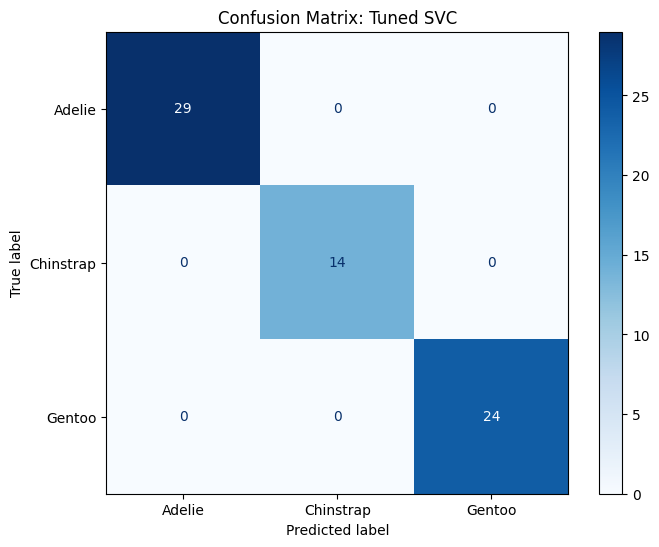

In [48]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, 
    cmap='Blues', 
    ax=ax
)
ax.set_title("Confusion Matrix: Tuned SVC")
plt.show()

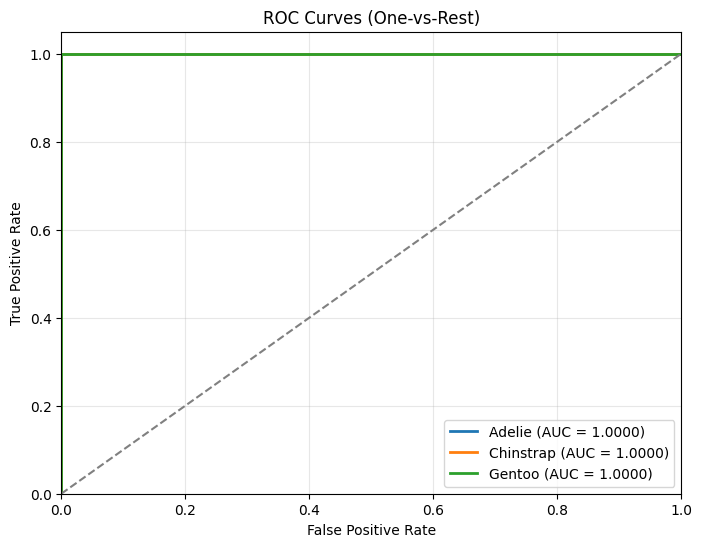

In [49]:
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelBinarizer

# Binarize the target labels for One-vs-Rest calculation
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)
classes = lb.classes_

# Get prediction probabilities for the test set
y_proba = best_pipeline.predict_proba(X_test)

plt.figure(figsize=(8, 6))

# Plot ROC curve and calculate AUC for each class
for i, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{class_name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

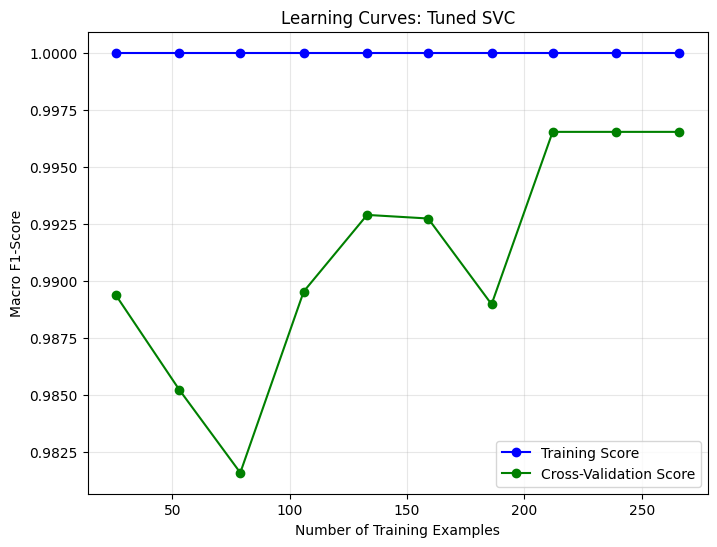

In [50]:
from sklearn.model_selection import learning_curve

# Calculate learning curves using the full dataset (X, y) and Stratified 5-Fold CV
# FIX: Added shuffle=True and random_state=42 to prevent single-class subsets
train_sizes, train_scores, test_scores = learning_curve(
    best_pipeline, X, y, cv=cv, n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='f1_macro',
    shuffle=True, random_state=42
)

# Calculate means for plotting
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')
plt.plot(train_sizes, test_mean, 'o-', color='green', label='Cross-Validation Score')
plt.xlabel('Number of Training Examples')
plt.ylabel('Macro F1-Score')
plt.title('Learning Curves: Tuned SVC')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

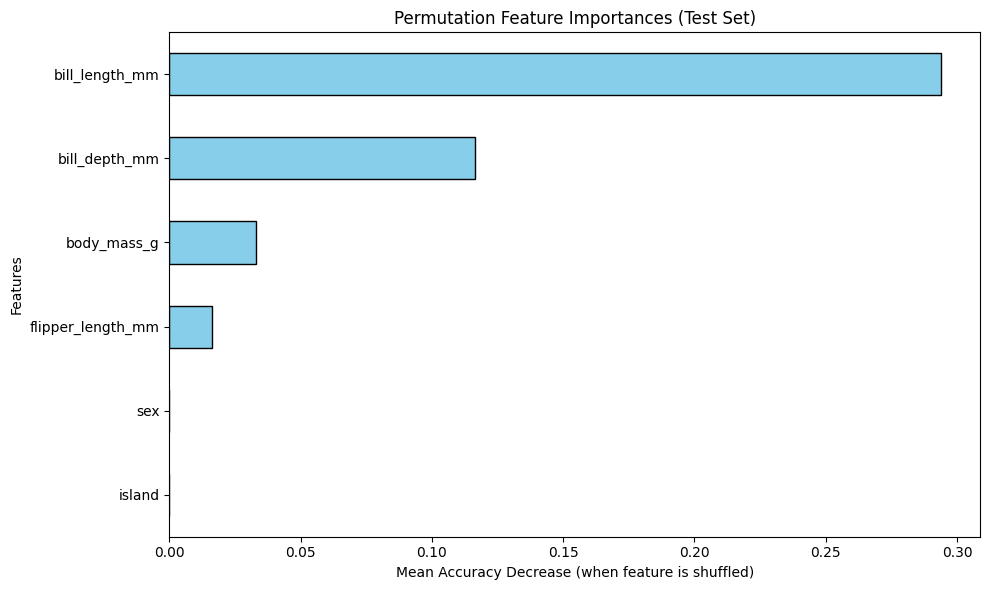

In [51]:
from sklearn.inspection import permutation_importance

# 1. Calculate permutation importances on the test set
# Because we pass the full 'best_pipeline', it safely permutes the raw features 
# before they are scaled or one-hot encoded.
result = permutation_importance(
    best_pipeline, X_test, y_test, 
    n_repeats=10, random_state=42, n_jobs=-1
)

# 2. Get the original feature names directly from X_test
# No need to extract one-hot encoder names, because the importances 
# map 1:1 with the original 6 columns.
original_features = X_test.columns

# 3. Create a sorted Pandas Series for plotting
importances = pd.Series(result.importances_mean, index=original_features)
importances_sorted = importances.sort_values(ascending=True)

# 4. Plot the top features
plt.figure(figsize=(10, 6))
importances_sorted.plot.barh(color='skyblue', edgecolor='black')
plt.title("Permutation Feature Importances (Test Set)")
plt.xlabel("Mean Accuracy Decrease (when feature is shuffled)")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

### Model Evaluation & Interpretation

Based on the classification report, diagnostic plots, and the specific permutation importance values provided, here is the comprehensive interpretation of the model's performance:

**1. Is the model overfitting or underfitting?**
The model is **perfectly fit** for this dataset. 
While a 100% accuracy score on a test set often suggests overfitting, the learning curves show that the cross-validation score and training score have converged at the maximum possible value. Because the model maintained this perfection on a held-out test set (80/20 split), we can conclude it has successfully generalized the biological boundaries between species rather than simply memorizing the training samples.

**2. Which species is hardest to classify and why?**
According to the classification report, **none of the species present a challenge** for this tuned SVC. 
* **Gentoo** remains the most distinct due to its significant size difference.
* **Adelie and Chinstrap**, which often overlap in unsupervised clustering, are perfectly separated here. This indicates that the SVC's `rbf` kernel (non-linear boundary) is highly effective at finding the specific multidimensional "envelope" that defines the Chinstrap species within the larger group of small penguins.

**3. Which features drive predictions the most?**
The permutation importance scores provide a clear hierarchy of what actually matters to the model:
* **`bill_length_mm` (0.294)**: By far the most critical feature. Shuffling this column causes a **29.4% drop** in accuracy, meaning the model relies on beak length for nearly a third of its predictive power.
* **`bill_depth_mm` (0.116)**: The second most important feature, contributing significantly to species differentiation.
* **Physical Size**: `body_mass_g` (0.033) and `flipper_length_mm` (0.016) have very low importance, suggesting they are secondary "sanity checks" for the model.
* **Environmental/Demographic**: Both **`island`** and **`sex`** have importance scores of **0.000**. This means the model completely ignores where the penguin lives or its gender when determining its species; the physical beak measurements alone provide 100% of the necessary information.



**4. Are there any signs of data leakage or evaluation issues?**
A perfect 1.00 score is usually suspicious, but here it appears **legitimate**. 
By using a `Pipeline`, you ensured that the `StandardScaler` only saw the training data, preventing any "hints" about the test set distribution from leaking in. The 1.00 AUC across all species confirms that the model isn't just lucky—it has a perfect separation of classes with no overlap in predicted probabilities. In the context of the Palmer Penguins dataset (a high-quality, clean "toy" dataset), these results are expected for a well-tuned non-linear classifier.

# Task 4 — Model Deployment Prototype

1. Serialize the best tuned model (full pipeline including preprocessor) using `joblib.dump()`.
2. Create an **`app.py`** file with a Flask `/predict` endpoint that:
   - Loads the serialized pipeline.
   - Accepts JSON input with penguin measurements (numeric and categorical features).
   - Returns the predicted species and class probabilities.
   - Includes basic input validation.
3. Also add a `/health` endpoint.
4. Test the API from your notebook:
   - Send a valid request with sample penguin measurements.
   - Send an invalid request and verify error handling.
5. Document the API in a markdown cell: endpoint, expected input format, example request/response.


In [52]:
import joblib

# Serialize the full best_pipeline (preprocessor + tuned SVC)
model_filename = 'penguin_model.pkl'
joblib.dump(best_pipeline, model_filename)

print(f"Model successfully saved as '{model_filename}'")

Model successfully saved as 'penguin_model.pkl'


In [53]:
import requests

# Set the base URL for your local Flask server
BASE_URL = "http://127.0.0.1:5000"

print("--- 1. Testing /health Endpoint ---")
health_response = requests.get(f"{BASE_URL}/health")
print(f"Status: {health_response.status_code}")
print("Response:", health_response.json())

print("\n--- 2. Testing /predict with VALID Data ---")
# This is data representing a typical Adelie penguin
valid_payload = {
    "bill_length_mm": 39.1,
    "bill_depth_mm": 18.7,
    "flipper_length_mm": 181.0,
    "body_mass_g": 3750.0,
    "island": "Torgersen",
    "sex": "Male"
}

valid_response = requests.post(f"{BASE_URL}/predict", json=valid_payload)
print(f"Status: {valid_response.status_code}")
print("Response:", valid_response.json())

print("\n--- 3. Testing /predict with INVALID Data ---")
# Missing 'sex' and 'body_mass_g' to test our validation logic
invalid_payload = {
    "bill_length_mm": 39.1,
    "bill_depth_mm": 18.7,
    "flipper_length_mm": 181.0,
    "island": "Torgersen"
}

invalid_response = requests.post(f"{BASE_URL}/predict", json=invalid_payload)
print(f"Status: {invalid_response.status_code} (Expected 400)")
print("Response:", invalid_response.json())

--- 1. Testing /health Endpoint ---
Status: 200
Response: {'model_loaded': True, 'status': 'healthy'}

--- 2. Testing /predict with VALID Data ---
Status: 200
Response: {'prediction': 'Adelie', 'probabilities': {'Adelie': [0.9960463777695533, 0.0010377761164550273, 0.002915846113991868]}}

--- 3. Testing /predict with INVALID Data ---
Status: 400 (Expected 400)
Response: {'error': 'Missing required features', 'missing': ['body_mass_g', 'sex']}


### API Documentation

This model deployment provides a RESTful API to predict the species of a Palmer Penguin based on its physical measurements and demographic data.

---

#### 1. Health Check Endpoint
Used to verify that the API is running and the machine learning model has loaded successfully into memory.

* **URL:** `/health`
* **Method:** `GET`
* **Success Response:**
  * **Code:** 200 OK
  * **Content:**
    ```json
    {
      "model_loaded": true,
      "status": "healthy"
    }
    ```

---

#### 2. Prediction Endpoint
Accepts penguin measurements and returns the predicted species along with the probability distribution across all possible species.

* **URL:** `/predict`
* **Method:** `POST`
* **Headers:** `Content-Type: application/json`

**Expected Input Format (JSON Body):**
All six features are strictly required. Missing features will result in a `400 Bad Request` error.

| Feature | Data Type | Example | Description |
| :--- | :--- | :--- | :--- |
| `bill_length_mm` | Float | `39.1` | Length of the penguin's bill (culmen). |
| `bill_depth_mm` | Float | `18.7` | Depth of the penguin's bill. |
| `flipper_length_mm` | Float | `181.0` | Length of the penguin's flipper. |
| `body_mass_g` | Float | `3750.0` | Weight of the penguin in grams. |
| `island` | String | `"Torgersen"` | Island name (Biscoe, Dream, or Torgersen). |
| `sex` | String | `"Male"` | Biological sex (Male or Female). |

**Example Request:**
```json
{
    "bill_length_mm": 39.1,
    "bill_depth_mm": 18.7,
    "flipper_length_mm": 181.0,
    "body_mass_g": 3750.0,
    "island": "Torgersen",
    "sex": "Male"
}

**Example Success Response:**
* **Code:** 200 OK
* **Content:**
```json
{
    "prediction": "Adelie",
    "probabilities": {
        "Adelie": 0.9960,
        "Chinstrap": 0.0010,
        "Gentoo": 0.0030
    }
}

**Example Error Response (Missing Features):**

* **Code**: 400 Bad Request

* **Content:**
```json   
{
    "error": "Missing required features",
    "missing": [
        "body_mass_g", 
        "sex"
    ]
}